# Unidad 1 · Basics of Neural Network — Roadkill Risk Engine

Este notebook reproduce las **pruebas de la Unidad 1** del notebook de referencia, pero adapta los ejercicios que dependen de datos reales a los artefactos incluidos en el ZIP del proyecto **Roadkill Risk Engine**.

## Archivos del ZIP utilizados

- `data/predicciones_test_2017.csv`
- `data/cell_coordinates_reto06.csv`

## Importante

El ZIP contiene artefactos históricos y predicciones ya generadas del proyecto, pero **no contiene la matriz exacta de variables con la que se entrenó el estimador original**. Por eso este notebook no pretende reconstruir ni reentrenar el modelo de producción.

Las pruebas de esta Unidad 1 tienen un objetivo **didáctico**: explicar perceptrones, redes multicapa, propagación hacia delante, gradientes, descenso de gradiente, funciones de activación, profundidad y *vanishing gradient* usando datos reales disponibles en el proyecto cuando corresponde.

## 0. Preparación del entorno

In [1]:
import sys
import random
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
from sklearn.model_selection import train_test_split
from IPython.display import display

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)

Python: 3.13.5
NumPy: 2.3.5
pandas: 2.2.3
scikit-learn: 1.8.0


### 0.1 Localización automática del ZIP

El notebook busca primero un ZIP de Roadkill V10 en la carpeta del notebook y, como alternativa, en `/mnt/data`.

In [2]:
def localizar_zip_roadkill():
    roots = [Path.cwd(), Path("/mnt/data")]
    patterns = [
        "*ROADKILL*V10*.zip",
        "*Roadkill*V10*.zip",
        "*roadkill*V10*.zip",
        "*ROADKILL*.zip",
        "*Roadkill*.zip",
        "*roadkill*.zip",
    ]
    encontrados = []
    for root in roots:
        if not root.exists():
            continue
        for pattern in patterns:
            encontrados.extend(root.glob(pattern))
    encontrados = list(dict.fromkeys(p.resolve() for p in encontrados if p.is_file()))
    if not encontrados:
        raise FileNotFoundError(
            "No se ha encontrado el ZIP del proyecto Roadkill. "
            "Coloca el ZIP en la misma carpeta que este notebook."
        )
    # Priorizamos V10 si hubiera varios ZIPs.
    encontrados.sort(key=lambda p: ("V10" not in p.name.upper(), len(p.name)))
    return encontrados[0]

ZIP_PATH = localizar_zip_roadkill()
EXTRACT_DIR = Path("roadkill_unidad1_extraido")
EXTRACT_DIR.mkdir(exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    zf.extractall(EXTRACT_DIR)

pred_path = next(EXTRACT_DIR.rglob("predicciones_test_2017.csv"))
coords_path = next(EXTRACT_DIR.rglob("cell_coordinates_reto06.csv"))

print("ZIP:", ZIP_PATH)
print("Predicciones:", pred_path)
print("Coordenadas/features de celda:", coords_path)

ZIP: /mnt/data/ROADKILL_INSURANCE_WEBAPP_REACT_FASTAPI_V10_DYNAMIC_RISK_VISUALS(1).zip
Predicciones: roadkill_unidad1_extraido/ROADKILL_INSURANCE_WEBAPP_REACT_FASTAPI_V10_DYNAMIC_RISK_VISUALS/data/predicciones_test_2017.csv
Coordenadas/features de celda: roadkill_unidad1_extraido/ROADKILL_INSURANCE_WEBAPP_REACT_FASTAPI_V10_DYNAMIC_RISK_VISUALS/data/cell_coordinates_reto06.csv


### 0.2 Carga, unión y auditoría mínima

La tabla de predicciones contiene una observación por `cell` y mes de 2017. La tabla de coordenadas añade descriptores de cada celda.

Usaremos:

- `target_presence`: 1 si hubo presencia de atropello en la observación y 0 en caso contrario.
- `dvc_count`: número observado de atropellos.
- `p_final`: probabilidad histórica ya calculada por el sistema del proyecto.
- variables de tráfico, geometría y localización de `cell_coordinates_reto06.csv`.

> `p_final` **no es una variable original cruda**. Es una salida probabilística ya generada por el sistema. Solo se usa en dos ejercicios didácticos para disponer de una señal 2D interpretable.

In [3]:
pred = pd.read_csv(pred_path)
coords = pd.read_csv(coords_path)

df = pred.merge(
    coords,
    on="cell",
    how="left",
    validate="many_to_one"
)

FEATURES_12 = [
    "month",
    "exposure_vkm_proxy",
    "easting_mean",
    "northing_mean",
    "log_traffic_mean",
    "log_traffic_max",
    "traffic_year_cv",
    "point_cv_mean",
    "log_link_length_km",
    "log_count_points",
    "road_category_n",
    "traffic_trend_pct_per_year",
]

required = [
    "cell", "target_presence", "dvc_count", "p_final"
] + FEATURES_12

missing_cols = [c for c in required if c not in df.columns]
assert not missing_cols, f"Faltan columnas esperadas: {missing_cols}"

print("Shape tras la unión:", df.shape)
print("Prevalencia target_presence:", f"{df['target_presence'].mean():.2%}")
print("Celdas únicas:", df["cell"].nunique())
print("Meses:", sorted(df["month"].dropna().unique().tolist()))
print("\nMissing en variables seleccionadas:")
display(df[required].isna().sum().to_frame("n_missing"))

df = df.dropna(subset=required).reset_index(drop=True)

print("\nShape utilizable:", df.shape)
display(df[required].head())

Shape tras la unión: (6372, 36)
Prevalencia target_presence: 17.98%
Celdas únicas: 531
Meses: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

Missing en variables seleccionadas:


,n_missing
cell,0
target_presence,0
dvc_count,0
p_final,0
month,0
exposure_vkm_proxy,0
easting_mean,48
northing_mean,48
log_traffic_mean,48
log_traffic_max,48



Shape utilizable: (6324, 36)


,cell,target_presence,dvc_count,p_final,month,exposure_vkm_proxy,easting_mean,northing_mean,log_traffic_mean,log_traffic_max,traffic_year_cv,point_cv_mean,log_link_length_km,log_count_points,road_category_n,traffic_trend_pct_per_year
0,4264,0,0,0.006999,1,40455.0,243000.0,539000.0,6.200712,6.259581,0.034492,0.0,1.252763,0.693147,1.0,0.008486
1,4264,0,0,0.005727,2,36540.0,243000.0,539000.0,6.200712,6.259581,0.034492,0.0,1.252763,0.693147,1.0,0.008486
2,4264,0,0,0.005444,3,40455.0,243000.0,539000.0,6.200712,6.259581,0.034492,0.0,1.252763,0.693147,1.0,0.008486
3,4264,0,0,0.006880,4,39150.0,243000.0,539000.0,6.200712,6.259581,0.034492,0.0,1.252763,0.693147,1.0,0.008486
4,4264,0,0,0.012496,5,40455.0,243000.0,539000.0,6.200712,6.259581,0.034492,0.0,1.252763,0.693147,1.0,0.008486


### 0.3 Split maestro 70/15/15

Se conserva la estructura del notebook de referencia: entrenamiento, validación y test. El reparto se estratifica por `target_presence`.

Este split se usa únicamente en estas pruebas pedagógicas de la Unidad 1. No debe interpretarse como una nueva validación temporal del sistema original.

In [4]:
idx_trainval, idx_test = train_test_split(
    df.index,
    test_size=0.15,
    random_state=SEED,
    stratify=df["target_presence"],
)

val_fraction = 0.15 / 0.85

idx_train, idx_val = train_test_split(
    idx_trainval,
    test_size=val_fraction,
    random_state=SEED,
    stratify=df.loc[idx_trainval, "target_presence"],
)

idx_train = pd.Index(idx_train)
idx_val = pd.Index(idx_val)
idx_test = pd.Index(idx_test)

split_info = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "n": [len(idx_train), len(idx_val), len(idx_test)],
})
split_info["%"] = 100 * split_info["n"] / len(df)

display(split_info)

for name, idx in [("train", idx_train), ("validation", idx_val), ("test", idx_test)]:
    print(
        f"{name:10s} | prevalencia positiva = "
        f"{df.loc[idx, 'target_presence'].mean():.2%}"
    )

,split,n,%
0,train,4426,69.987350
1,validation,949,15.006325
2,test,949,15.006325


train      | prevalencia positiva = 18.12%
validation | prevalencia positiva = 18.12%
test       | prevalencia positiva = 18.12%


# UNIDAD 1 · Basics of Neural Network
## Del perceptrón a Deep Learning

# 1.1 Understanding Perceptron
## 1.1.A De una neurona artificial a una decisión

Esta prueba es conceptual y, por tanto, no depende del dataset. Se reproduce la función escalón aplicada a las puertas lógicas OR y AND.

In [5]:
def step_pm1(z):
    z = np.asarray(z)
    return np.where(z >= 0, 1, -1)

X_logic = np.array(
    [[0, 0], [1, 0], [0, 1], [1, 1]],
    dtype=float
)

z_or = -0.5 + X_logic @ np.array([1.0, 1.0])
print("OR:")
display(pd.DataFrame({
    "x1": X_logic[:, 0],
    "x2": X_logic[:, 1],
    "z": z_or,
    "y": step_pm1(z_or),
}))

z_and = -1.5 + X_logic @ np.array([1.0, 1.0])
print("AND:")
display(pd.DataFrame({
    "x1": X_logic[:, 0],
    "x2": X_logic[:, 1],
    "z": z_and,
    "y": step_pm1(z_and),
}))

OR:


,x1,x2,z,y
0,0.0,0.0,-0.5,-1
1,1.0,0.0,0.5,1
2,0.0,1.0,0.5,1
3,1.0,1.0,1.5,1


AND:


,x1,x2,z,y
0,0.0,0.0,-1.5,-1
1,1.0,0.0,-0.5,-1
2,0.0,1.0,-0.5,-1
3,1.0,1.0,0.5,1


**Interpretación.** Un perceptrón calcula una combinación lineal de las entradas, añade un sesgo y aplica una regla de decisión. En OR y AND basta una única frontera lineal.

## 1.1.B Perceptrón con datos reales del proyecto

En el notebook de vinos se utilizaban dos variables reales para distinguir dos clases. Aquí se mantiene la misma idea:

- entrada 1: `p_final`, score probabilístico histórico ya generado por el proyecto;
- entrada 2: `month`;
- objetivo: `target_presence`, convertido a -1 / +1.

La prueba **no reentrena el modelo original**: comprueba cómo se comporta un perceptrón lineal muy simple sobre dos señales disponibles en el ZIP.

In [6]:
features_2d = ["p_final", "month"]

Xtr2 = df.loc[idx_train, features_2d].to_numpy(dtype=np.float64)
Xva2 = df.loc[idx_val, features_2d].to_numpy(dtype=np.float64)

ytr2 = np.where(
    df.loc[idx_train, "target_presence"].to_numpy() == 1,
    1,
    -1
)
yva2 = np.where(
    df.loc[idx_val, "target_presence"].to_numpy() == 1,
    1,
    -1
)

mu2 = Xtr2.mean(axis=0)
sd2 = Xtr2.std(axis=0, ddof=0)
sd2 = np.where(sd2 == 0, 1.0, sd2)

Xtr2s = (Xtr2 - mu2) / sd2
Xva2s = (Xva2 - mu2) / sd2

def train_perceptron(X, y, lr=0.02, epochs=40):
    w = np.zeros(X.shape[1], dtype=float)
    b = 0.0
    history = []

    for epoch in range(epochs):
        mistakes = 0
        for xi, yi in zip(X, y):
            pred = 1 if (xi @ w + b) >= 0 else -1
            if pred != yi:
                w += lr * yi * xi
                b += lr * yi
                mistakes += 1
        history.append(mistakes)

    return w, b, np.array(history)

w_p, b_p, hist_p = train_perceptron(Xtr2s, ytr2)

pred_tr = np.where(Xtr2s @ w_p + b_p >= 0, 1, -1)
pred_va = np.where(Xva2s @ w_p + b_p >= 0, 1, -1)

acc_train = (pred_tr == ytr2).mean()
acc_val = (pred_va == yva2).mean()
baseline_val = max(
    (yva2 == -1).mean(),
    (yva2 == 1).mean()
)

print("Pesos:", w_p)
print("Bias:", b_p)
print(f"Accuracy train:      {acc_train:.4f}")
print(f"Accuracy validation: {acc_val:.4f}")
print(f"Baseline mayoritaria validation: {baseline_val:.4f}")

Pesos: [0.02715411 0.00278127]
Bias: -0.019999999999999993
Accuracy train:      0.8479
Accuracy validation: 0.8462
Baseline mayoritaria validation: 0.8188


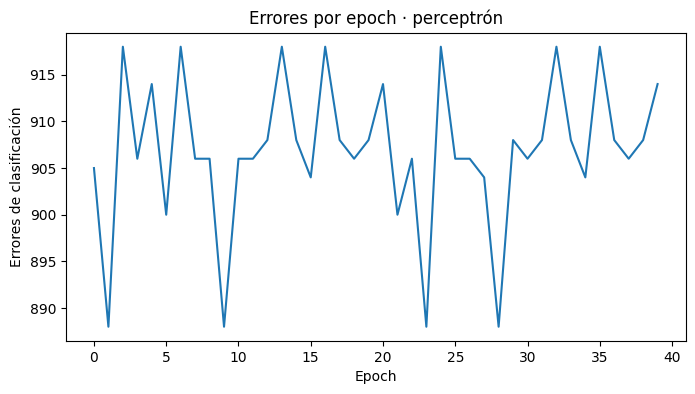

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(hist_p)
plt.title("Errores por epoch · perceptrón")
plt.xlabel("Epoch")
plt.ylabel("Errores de clasificación")
plt.show()

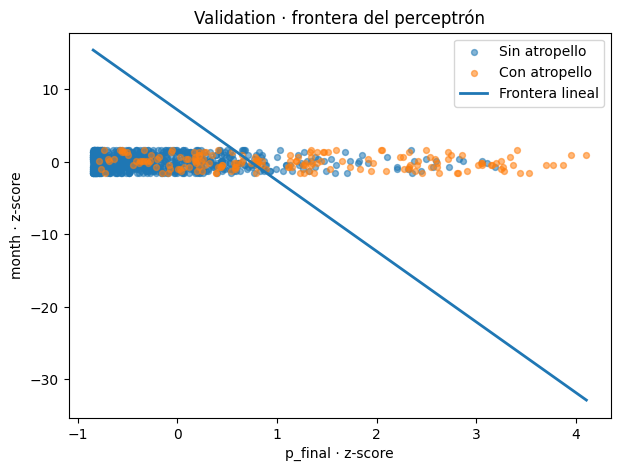

In [8]:
plt.figure(figsize=(7, 5))

for cls, label in [(-1, "Sin atropello"), (1, "Con atropello")]:
    m = yva2 == cls
    plt.scatter(
        Xva2s[m, 0],
        Xva2s[m, 1],
        s=18,
        alpha=0.55,
        label=label
    )

xx = np.linspace(Xva2s[:, 0].min(), Xva2s[:, 0].max(), 200)

if abs(w_p[1]) > 1e-12:
    yy = -(w_p[0] * xx + b_p) / w_p[1]
    plt.plot(xx, yy, linewidth=2, label="Frontera lineal")

plt.xlabel("p_final · z-score")
plt.ylabel("month · z-score")
plt.title("Validation · frontera del perceptrón")
plt.legend()
plt.show()

**Interpretación.** El perceptrón solo puede crear una frontera recta en este espacio 2D. La comparación con la clase mayoritaria es importante porque el conjunto está desbalanceado: una accuracy alta, por sí sola, no demuestra que el modelo haya aprendido una separación útil.

Además, `p_final` ya resume información de un sistema anterior. Por tanto, esta prueba sirve para estudiar el comportamiento del perceptrón, no para afirmar que estas dos variables constituyan un nuevo modelo de atropellos.

# 1.2 Understanding Multilayer Perceptron
## 1.2.A XOR y no separabilidad lineal

,x1,x2,XOR
0,0.0,0.0,0
1,0.0,1.0,1
2,1.0,0.0,1
3,1.0,1.0,0


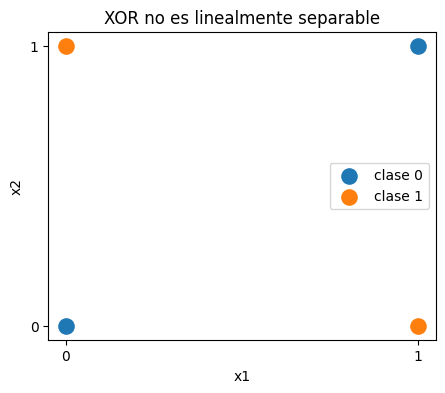

In [9]:
X_xor = np.array(
    [[0, 0], [0, 1], [1, 0], [1, 1]],
    dtype=float
)
y_xor = np.array([0, 1, 1, 0])

display(pd.DataFrame({
    "x1": X_xor[:, 0],
    "x2": X_xor[:, 1],
    "XOR": y_xor
}))

plt.figure(figsize=(5, 4))
for cls in [0, 1]:
    m = y_xor == cls
    plt.scatter(
        X_xor[m, 0],
        X_xor[m, 1],
        s=120,
        label=f"clase {cls}"
    )

plt.xticks([0, 1])
plt.yticks([0, 1])
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("XOR no es linealmente separable")
plt.legend()
plt.show()

**Interpretación.** XOR coloca las clases en esquinas opuestas. No existe una única línea recta capaz de separarlas correctamente, lo que muestra una limitación esencial de un perceptrón aislado.

## 1.2.B Resolver XOR con perceptrones

In [10]:
def unit_step01(z):
    return (np.asarray(z) >= 0).astype(int)

def gate_or(X):
    return unit_step01(-0.5 + X @ np.array([1.0, 1.0]))

def gate_nand(X):
    return unit_step01(1.5 + X @ np.array([-1.0, -1.0]))

h1 = gate_or(X_xor)
h2 = gate_nand(X_xor)

H = np.c_[h1, h2]

y_hat_xor = unit_step01(
    -1.5 + H @ np.array([1.0, 1.0])
)

result_xor = pd.DataFrame({
    "x1": X_xor[:, 0],
    "x2": X_xor[:, 1],
    "hidden_OR": h1,
    "hidden_NAND": h2,
    "XOR_real": y_xor,
    "XOR_pred": y_hat_xor
})

display(result_xor)

assert np.array_equal(y_xor, y_hat_xor)
print("✓ La red multicapa de umbral resuelve XOR.")

,x1,x2,hidden_OR,hidden_NAND,XOR_real,XOR_pred
0,0.0,0.0,0,1,0,0
1,0.0,1.0,1,1,1,1
2,1.0,0.0,1,1,1,1
3,1.0,1.0,1,0,0,0


✓ La red multicapa de umbral resuelve XOR.


**Interpretación.** Varias neuronas sencillas pueden construir representaciones intermedias y resolver un problema que una única frontera lineal no puede resolver. Esta es la idea básica que conduce a los perceptrones multicapa.

# 1.3 From MLP to Deep Learning
## 1.3.A Forward propagation con una observación real

In [11]:
sample = df.loc[
    idx_train[0],
    ["p_final", "month"]
].to_numpy(dtype=float)

sample_s = (sample - mu2) / sd2

W1 = np.array([
    [0.8, -0.3, 0.5],
    [-0.6, 0.9, 0.2]
])
b1 = np.array([0.1, -0.2, 0.0])

W2 = np.array([
    [0.7],
    [-0.4],
    [0.9]
])
b2 = np.array([0.05])

def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

z1 = sample_s @ W1 + b1
a1 = relu(z1)
z2 = a1 @ W2 + b2
yhat = sigmoid(z2)[0]

print("Entrada original [p_final, month]:", sample)
print("Entrada estandarizada:", sample_s)
print("z1:", z1)
print("a1 = ReLU(z1):", a1)
print("z2:", z2[0])
print("salida sigmoid:", yhat)

Entrada original [p_final, month]: [0.05727573 2.        ]
Entrada estandarizada: [-0.54534962 -1.29709602]
z1: [ 0.44197792 -1.20378153 -0.53209401]
a1 = ReLU(z1): [0.44197792 0.         0.        ]
z2: 0.3593845405710696
salida sigmoid: 0.5888914405259403


**Interpretación.** El *forward pass* muestra, paso a paso, cómo una observación atraviesa la red: combinación lineal → ReLU → nueva combinación lineal → sigmoid. Los pesos son manuales, por lo que la salida no debe interpretarse como una predicción validada del proyecto.

# 1.4 Gradientes y aprendizaje
## 1.4.B Gradient check

Se conserva la prueba sintética del notebook original porque su objetivo es verificar las matemáticas del gradiente, no el dataset.

In [12]:
x = np.array([1.0, 2.0, 3.0])
y = np.array([2.0, 4.1, 5.9])

w = 1.4
b = 0.2

def mse_wb(w, b):
    return np.mean((y - (w * x + b)) ** 2)

yhat_lin = w * x + b

dL_dw = np.mean(2 * (yhat_lin - y) * x)
dL_db = np.mean(2 * (yhat_lin - y))

eps = 1e-6

num_dw = (
    mse_wb(w + eps, b) - mse_wb(w - eps, b)
) / (2 * eps)

num_db = (
    mse_wb(w, b + eps) - mse_wb(w, b - eps)
) / (2 * eps)

print("dL/dw analítico:", dL_dw, "numérico:", num_dw)
print("dL/db analítico:", dL_db, "numérico:", num_db)

assert np.isclose(dL_dw, num_dw, rtol=1e-5, atol=1e-7)
assert np.isclose(dL_db, num_db, rtol=1e-5, atol=1e-7)

print("✓ Gradiente analítico = gradiente numérico.")

dL/dw analítico: -4.733333333333335 numérico: -4.733333333173384
dL/db analítico: -2.0000000000000004 numérico: -2.0000000000575113
✓ Gradiente analítico = gradiente numérico.


**Interpretación.** Si el gradiente analítico y el numérico coinciden, tenemos una comprobación independiente de que la derivada implementada es correcta.

## 1.4.C Gradient descent: exposición vial → número de atropellos

El notebook de referencia aprendía una relación lineal `alcohol → quality`. Aquí se adapta a:

- entrada: `exposure_vkm_proxy`;
- objetivo: `dvc_count`.

Es una regresión lineal didáctica con descenso de gradiente. No se presenta como el modelo adecuado para conteos ni como sustituto del sistema original.

In [13]:
x_train_exp = df.loc[
    idx_train,
    "exposure_vkm_proxy"
].to_numpy(dtype=float)

y_train_count = df.loc[
    idx_train,
    "dvc_count"
].to_numpy(dtype=float)

x_mean = x_train_exp.mean()
x_std = x_train_exp.std()

xz = (x_train_exp - x_mean) / x_std

w = 0.0
b = y_train_count.mean()
lr = 0.03
loss_hist = []

for epoch in range(200):
    pred_count = w * xz + b
    err = pred_count - y_train_count

    loss = np.mean(err ** 2)

    w -= lr * np.mean(2 * err * xz)
    b -= lr * np.mean(2 * err)

    loss_hist.append(loss)

print(f"w={w:.4f}, b={b:.4f}, MSE={loss_hist[-1]:.4f}")
print(f"MSE inicial={loss_hist[0]:.4f}")
print(f"Reducción del MSE={loss_hist[0] - loss_hist[-1]:.4f}")

w=0.4654, b=0.3068, MSE=0.5799
MSE inicial=0.7965
Reducción del MSE=0.2166


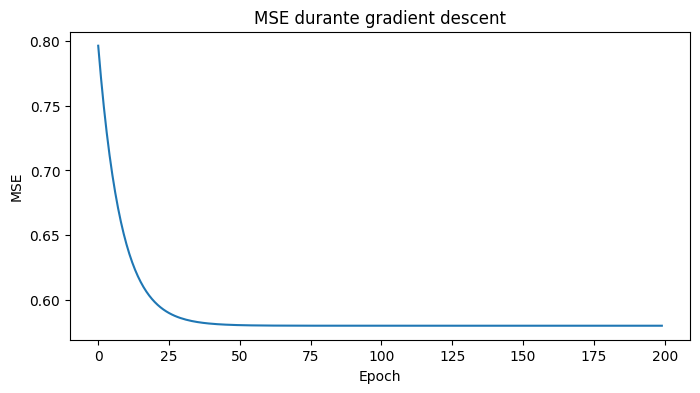

In [14]:
plt.figure(figsize=(8, 4))
plt.plot(loss_hist)
plt.title("MSE durante gradient descent")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()

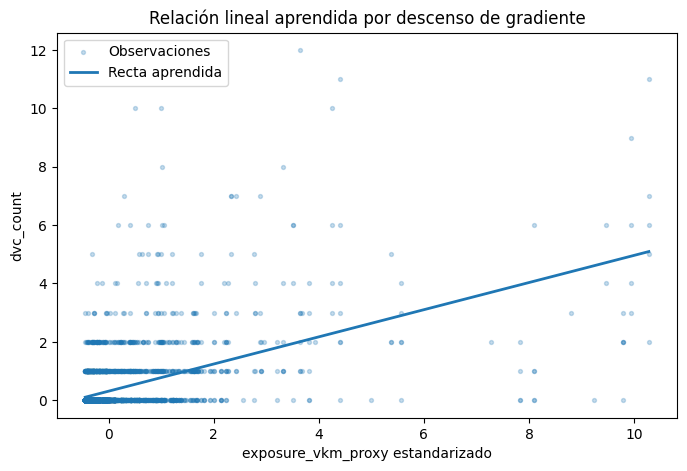

In [15]:
plt.figure(figsize=(8, 5))
plt.scatter(
    xz,
    y_train_count,
    s=8,
    alpha=0.25,
    label="Observaciones"
)

xx = np.linspace(xz.min(), xz.max(), 200)
plt.plot(
    xx,
    w * xx + b,
    linewidth=2,
    label="Recta aprendida"
)

plt.xlabel("exposure_vkm_proxy estandarizado")
plt.ylabel("dvc_count")
plt.title("Relación lineal aprendida por descenso de gradiente")
plt.legend()
plt.show()

**Interpretación.** Si el MSE disminuye, el algoritmo está ajustando `w` y `b` en una dirección que reduce el error cuadrático. La relación aprendida es deliberadamente simple: un fenómeno de conteo como `dvc_count` puede requerir modelos más adecuados que una regresión lineal.

# 1.5 Activation Functions
## 1.5.A Sigmoid, Tanh, ReLU y Leaky ReLU

Estas pruebas son matemáticas y no dependen del dataset.

In [16]:
z = np.linspace(-6, 6, 600)

sig = 1 / (1 + np.exp(-z))
tanh_v = np.tanh(z)
relu_v = np.maximum(0, z)
leaky_v = np.where(z >= 0, z, 0.1 * z)

sig_d = sig * (1 - sig)
tanh_d = 1 - tanh_v ** 2
relu_d = (z > 0).astype(float)
leaky_d = np.where(z >= 0, 1.0, 0.1)

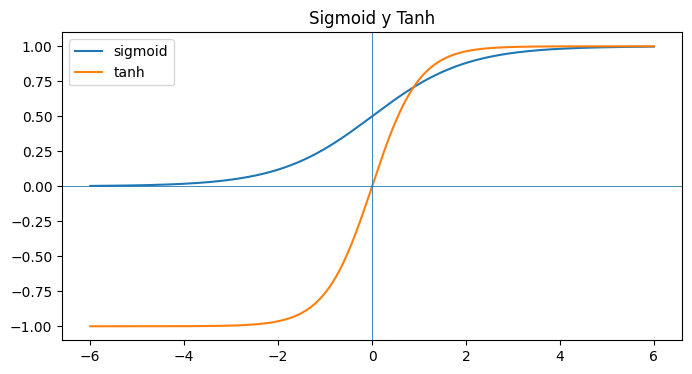

In [17]:
plt.figure(figsize=(8, 4))
plt.plot(z, sig, label="sigmoid")
plt.plot(z, tanh_v, label="tanh")
plt.axhline(0, linewidth=0.6)
plt.axvline(0, linewidth=0.6)
plt.title("Sigmoid y Tanh")
plt.legend()
plt.show()

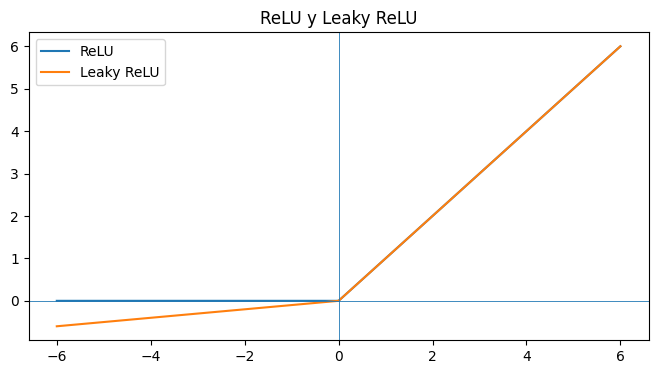

In [18]:
plt.figure(figsize=(8, 4))
plt.plot(z, relu_v, label="ReLU")
plt.plot(z, leaky_v, label="Leaky ReLU")
plt.axhline(0, linewidth=0.6)
plt.axvline(0, linewidth=0.6)
plt.title("ReLU y Leaky ReLU")
plt.legend()
plt.show()

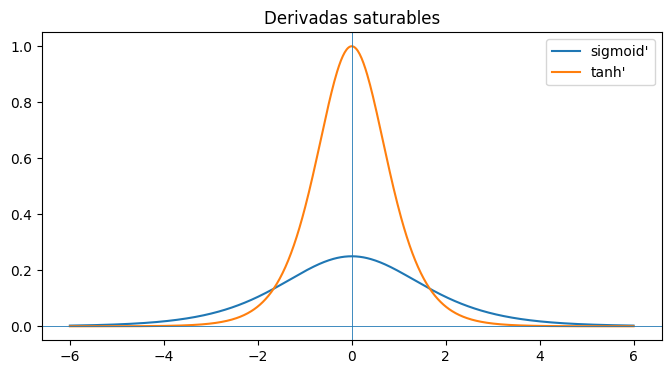

In [19]:
plt.figure(figsize=(8, 4))
plt.plot(z, sig_d, label="sigmoid'")
plt.plot(z, tanh_d, label="tanh'")
plt.axhline(0, linewidth=0.6)
plt.axvline(0, linewidth=0.6)
plt.title("Derivadas saturables")
plt.legend()
plt.show()

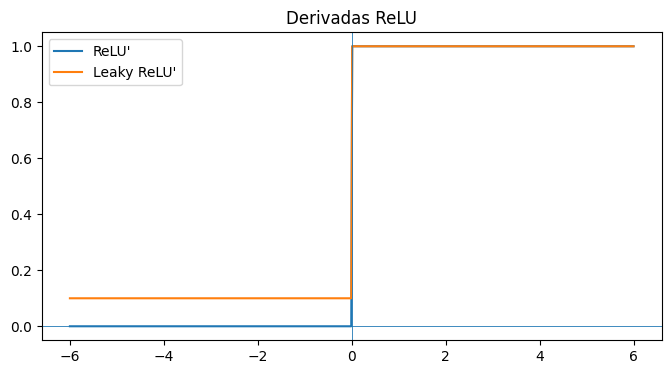

In [20]:
plt.figure(figsize=(8, 4))
plt.plot(z, relu_d, label="ReLU'")
plt.plot(z, leaky_d, label="Leaky ReLU'")
plt.axhline(0, linewidth=0.6)
plt.axvline(0, linewidth=0.6)
plt.title("Derivadas ReLU")
plt.legend()
plt.show()

**Interpretación.** Las funciones de activación introducen no linealidad. Sus derivadas también determinan cómo se propaga la señal de aprendizaje durante el entrenamiento.

## 1.5.B Softmax estable

Se conserva la prueba original. Para relacionarla con el proyecto, podemos interpretar las tres salidas como tres categorías hipotéticas de riesgo: bajo, medio y alto.

In [21]:
logits = np.array([1.2, 0.4, -0.2])

shifted = logits - logits.max()
probs = np.exp(shifted) / np.exp(shifted).sum()

risk_labels = ["bajo", "medio", "alto"]

display(pd.DataFrame({
    "categoria": risk_labels,
    "logit": logits,
    "probabilidad": probs
}))

print("Suma de probabilidades:", probs.sum())

,categoria,logit,probabilidad
0,bajo,1.2,0.589648
1,medio,0.4,0.264946
2,alto,-0.2,0.145406


Suma de probabilidades: 1.0


**Interpretación.** Softmax convierte puntuaciones internas en una distribución de probabilidades que suma 1. Restar el máximo antes de exponentiar mejora la estabilidad numérica sin alterar el resultado final.

# 1.6 Deep Learning
## 1.6.A Profundidad y número de parámetros

Para mantener la misma prueba que el notebook de referencia, seleccionamos **12 variables numéricas disponibles en el ZIP**. Esto no significa que fueran exactamente las 12 variables del estimador histórico: se usan únicamente para dimensionar ejemplos de arquitectura.

In [22]:
print("Variables consideradas para el ejemplo:")
for i, feature in enumerate(FEATURES_12, start=1):
    print(f"{i:2d}. {feature}")

N_INPUTS = len(FEATURES_12)
assert N_INPUTS == 12

def dense_params(n_in, n_out):
    return n_in * n_out + n_out

architectures = {
    f"Lineal {N_INPUTS}→1": [N_INPUTS, 1],
    f"MLP {N_INPUTS}→16→1": [N_INPUTS, 16, 1],
    f"MLP {N_INPUTS}→64→32→1": [N_INPUTS, 64, 32, 1],
    f"MLP profundo {N_INPUTS}→128→128→64→32→1": [
        N_INPUTS, 128, 128, 64, 32, 1
    ],
}

rows = []

for name, layers in architectures.items():
    n_params = sum(
        dense_params(a, b)
        for a, b in zip(layers[:-1], layers[1:])
    )
    rows.append((name, n_params))

display(pd.DataFrame(
    rows,
    columns=["Arquitectura", "Parámetros"]
))

Variables consideradas para el ejemplo:
 1. month
 2. exposure_vkm_proxy
 3. easting_mean
 4. northing_mean
 5. log_traffic_mean
 6. log_traffic_max
 7. traffic_year_cv
 8. point_cv_mean
 9. log_link_length_km
10. log_count_points
11. road_category_n
12. traffic_trend_pct_per_year


,Arquitectura,Parámetros
0,Lineal 12→1,13
1,MLP 12→16→1,225
2,MLP 12→64→32→1,2945
3,MLP profundo 12→128→128→64→32→1,28545


**Interpretación.** Añadir capas y neuronas aumenta rápidamente el número de parámetros. Más capacidad no implica automáticamente un modelo mejor: también aumenta el riesgo de sobreajuste y el coste de entrenamiento.

# 1.7 Problems of Deep Learning
## 1.7.A Vanishing gradient

Se reproduce la prueba conceptual del notebook de referencia.

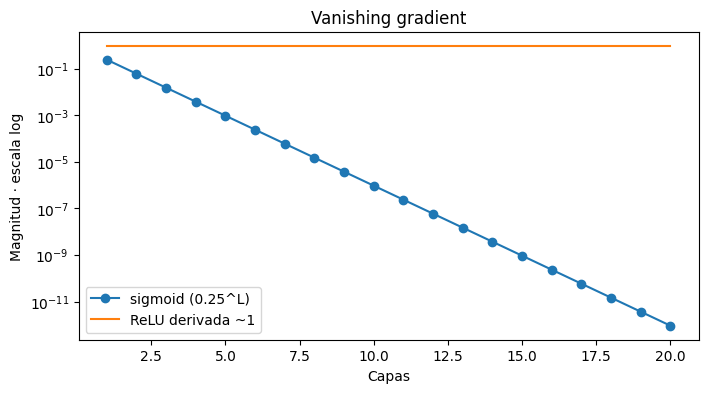

Gradiente aproximado sigmoid en capa 20: 9.095e-13
Gradiente aproximado ReLU en capa 20: 1.0


In [23]:
layers = np.arange(1, 21)

approx_sigmoid_chain = 0.25 ** layers
approx_relu_chain = np.ones_like(layers, dtype=float)

plt.figure(figsize=(8, 4))
plt.semilogy(
    layers,
    approx_sigmoid_chain,
    marker="o",
    label="sigmoid (0.25^L)"
)
plt.semilogy(
    layers,
    approx_relu_chain,
    label="ReLU derivada ~1"
)

plt.xlabel("Capas")
plt.ylabel("Magnitud · escala log")
plt.title("Vanishing gradient")
plt.legend()
plt.show()

print(
    "Gradiente aproximado sigmoid en capa 20:",
    f"{approx_sigmoid_chain[-1]:.3e}"
)
print(
    "Gradiente aproximado ReLU en capa 20:",
    f"{approx_relu_chain[-1]:.1f}"
)

**Interpretación.** En esta simplificación, encadenar derivadas máximas de sigmoid (`0.25`) hace que el gradiente disminuya exponencialmente. Con 20 capas, `0.25^20` es prácticamente cero. La aproximación de ReLU activa mantiene una derivada cercana a 1.

La gráfica es intencionadamente simplificada: ReLU también puede tener derivada 0 para entradas negativas.

# Resumen de equivalencias respecto al notebook de referencia

| Prueba | Notebook de vinos | Adaptación Roadkill |
|---|---|---|
| 1.1.A OR / AND | Conceptual | Igual |
| 1.1.B Perceptrón | alcohol + acidez → premium | `p_final` + mes → `target_presence` |
| 1.2.A XOR | Conceptual | Igual |
| 1.2.B XOR multicapa | Conceptual | Igual |
| 1.3.A Forward pass | muestra real de vino | muestra real de Roadkill (`p_final`, mes) |
| 1.4.B Gradient check | Sintético | Igual |
| 1.4.C Gradient descent | alcohol → quality | exposición vial → `dvc_count` |
| 1.5 Activaciones | Conceptual | Igual |
| 1.5.B Softmax | Conceptual | Igual, interpretado como bandas de riesgo |
| 1.6 Parámetros | 12 entradas | 12 variables numéricas disponibles del ZIP |
| 1.7 Vanishing gradient | Conceptual | Igual |

## Conclusión

La estructura y las pruebas fundamentales de la Unidad 1 se mantienen. Solo se sustituyen los ejercicios que necesitan observaciones reales por variables y objetivos presentes en el ZIP de Roadkill, señalando expresamente cuándo una columna es una predicción precomputada y cuándo una prueba es puramente conceptual.